### Import necessary libraries and modules

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor  
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.cluster import KMeans


### Load data

In [2]:
df=pd.read_csv('housing.csv') 

### Understanding the data 


In [3]:
df.info()
df.isnull().sum()


<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


We have a complete dataset in the majority of variables. However, missingness occurs in the variable total_bedrooms (n=207)

### Split our data

In [4]:
train,test = train_test_split(df, test_size=0.2, random_state=42)   


### EDA on training dataset


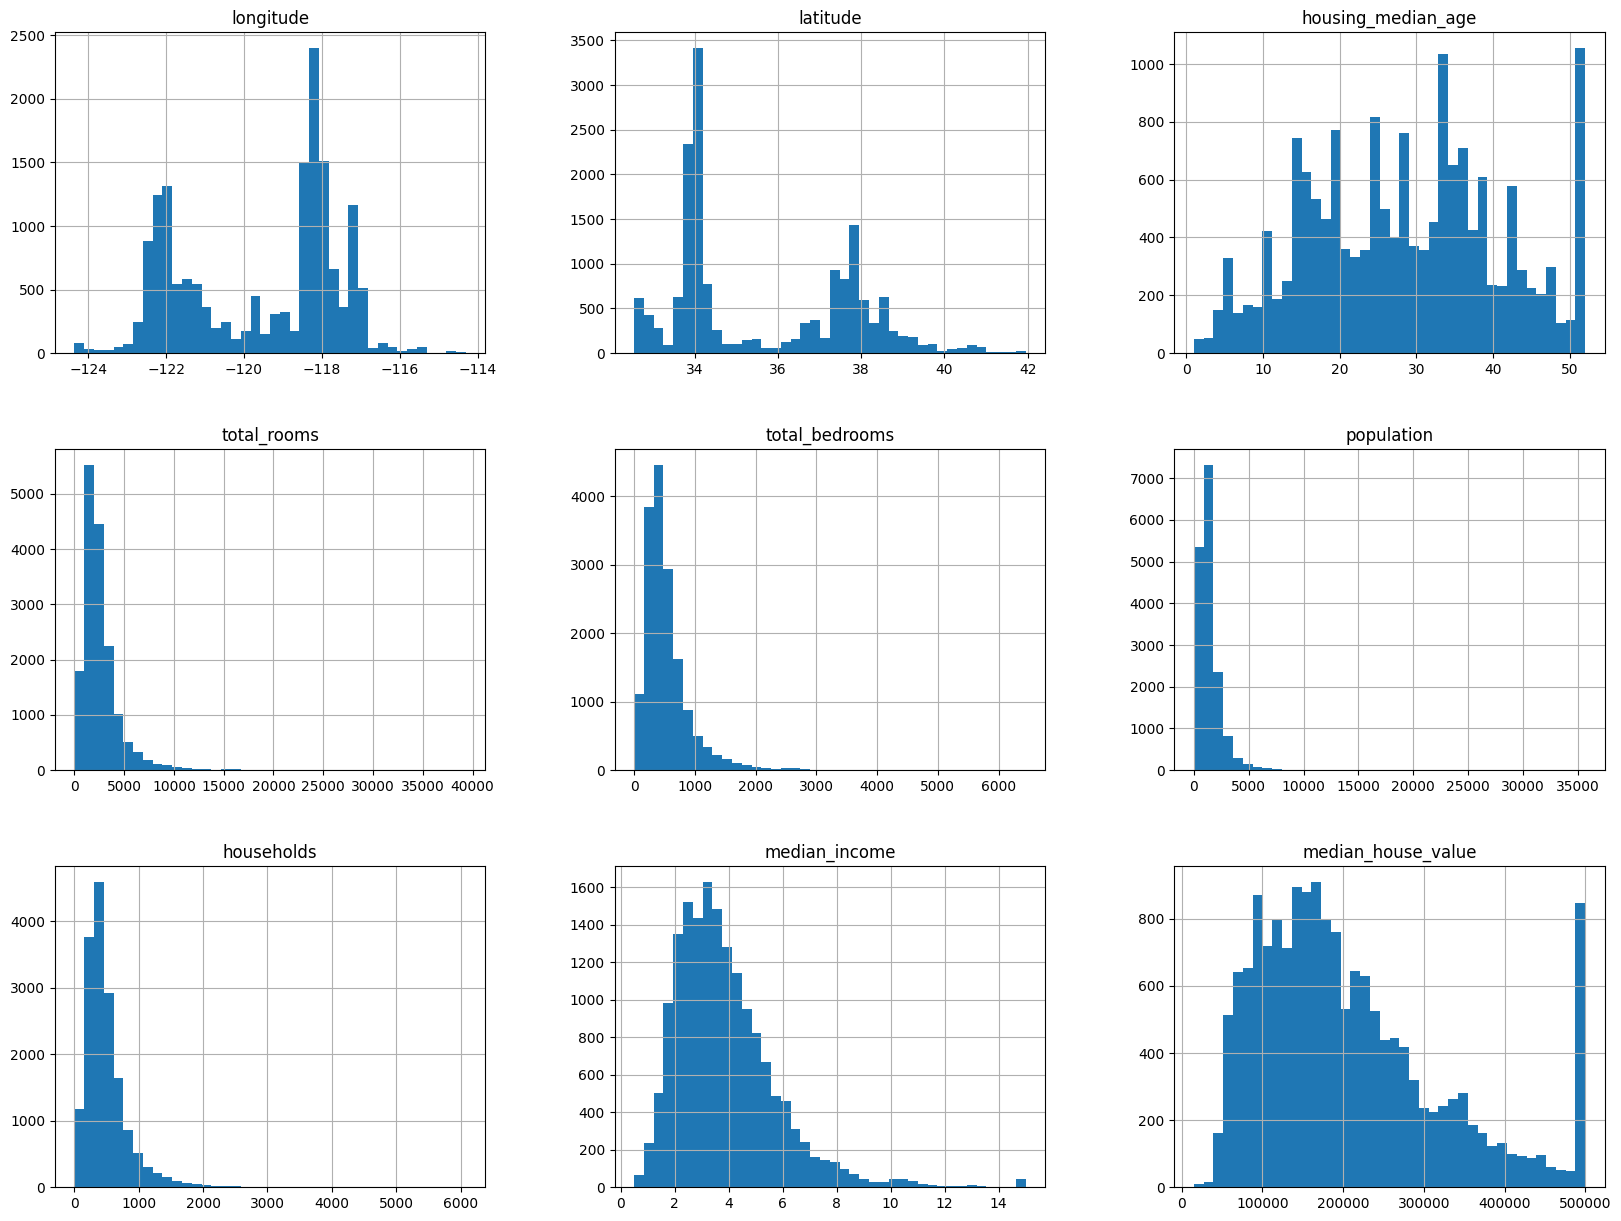

In [5]:
train.hist(bins=40, figsize=(20,15))
plt.show()

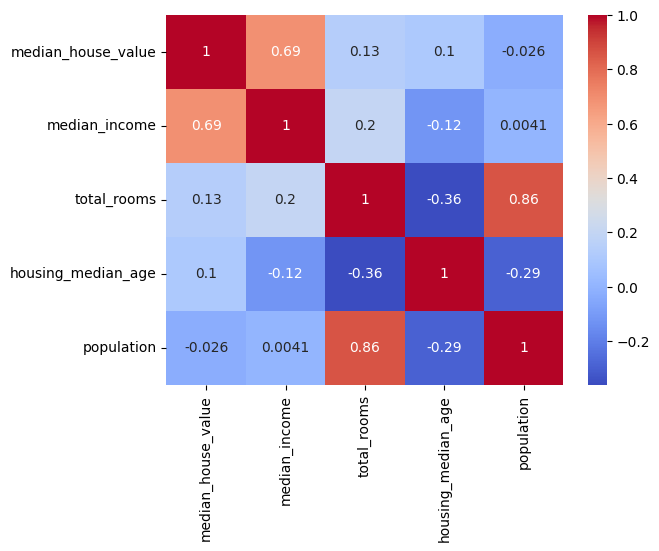

In [6]:
corr= train[['median_house_value','median_income','total_rooms','housing_median_age','population']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()


In [7]:
train.columns
#convert to category 
train['ocean_proximity'] = train['ocean_proximity'].astype('category')
train['total_bedrooms'] = train['total_bedrooms'].astype('float')

train[['ocean_proximity']].value_counts(normalize=True)



ocean_proximity
<1H OCEAN          0.444586
INLAND             0.316558
NEAR OCEAN         0.126332
NEAR BAY           0.112282
ISLAND             0.000242
Name: proportion, dtype: float64

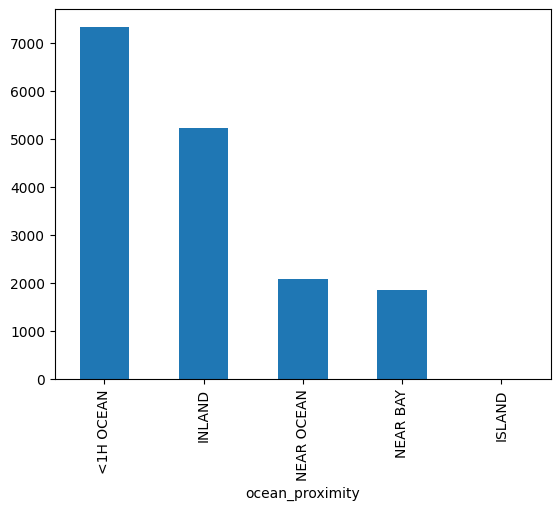

In [8]:
train['ocean_proximity'].value_counts().plot(kind='bar')
plt.show()

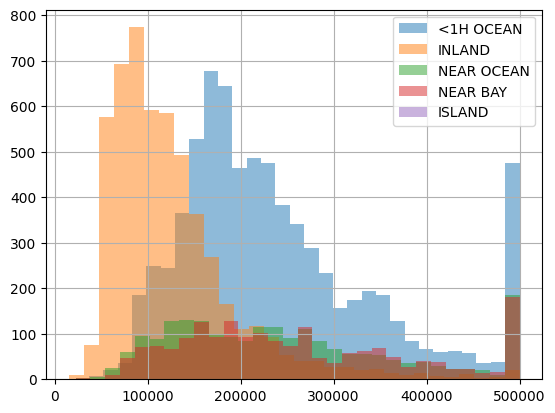

In [9]:
train.query('ocean_proximity == "<1H OCEAN"')['median_house_value'].hist(bins=30, alpha=0.5, label='<1H OCEAN')
train.query('ocean_proximity == "INLAND"')['median_house_value'].hist(bins=30, alpha=0.5, label='INLAND')
train.query('ocean_proximity == "NEAR OCEAN"')['median_house_value'].hist(bins=30, alpha=0.5, label='NEAR OCEAN')
train.query('ocean_proximity == "NEAR BAY"')['median_house_value'].hist(bins=30, alpha=0.5, label='NEAR BAY')
train.query('ocean_proximity == "ISLAND"')['median_house_value'].hist(bins=30, alpha=0.5, label='ISLAND')
plt.legend()    

In [11]:
x_train = train.drop('median_house_value', axis=1)
y_train = train['median_house_value']

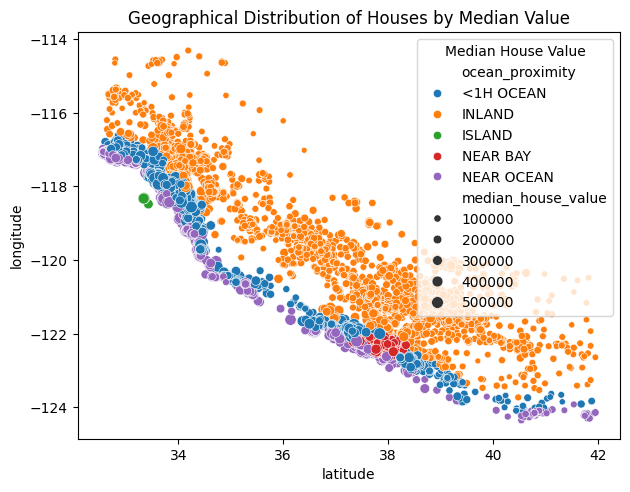

In [14]:
sns.scatterplot(
    x=x_train['latitude'], 
    y=x_train['longitude'],
    hue=x_train['ocean_proximity'],
    size=y_train
)
plt.legend(title='Median House Value')
plt.tight_layout()
plt.title('Geographical Distribution of Houses by Median Value')
plt.show()

The plot shows higher prices for houses located at coastal areas. Houses that are in Islands, near the ocean, near the bay are more expensive compared to houses in Inland

### Evaluation

In [15]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = 'r2'

# Define features
numeric_features = ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
categorical_features = ['ocean_proximity']

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder())
        ]), categorical_features)
    ]
)

### Models

In [16]:
baseline_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), 
    ('model', LinearRegression())
    ])

baselinegrid = GridSearchCV(estimator=baseline_pipeline, param_grid={}, scoring=scoring, cv=cv, n_jobs=-1)
baselinegrid.fit(x_train, y_train)
print("Linear Regression - CV R2:", baselinegrid.best_score_)

lasso_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),  
    ('model', Lasso())
    ])
lasso_param_grid = {
    "model__alpha": [0.001, 0.01, 0.1, 1.0, 10.0]
}
Lasso_grid = GridSearchCV(estimator=lasso_pipeline, param_grid=lasso_param_grid, scoring=scoring, cv=cv, n_jobs=-1)
Lasso_grid.fit(x_train, y_train)    
print("Lasso - CV R2:", Lasso_grid.best_score_)

ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),  
    ('model', Ridge())
    ])
ridge_param_grid = {
    "model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]
}

ridge_grid = GridSearchCV(estimator=ridge_pipeline, param_grid=ridge_param_grid, scoring=scoring, cv=cv, n_jobs=-1)
ridge_grid.fit(x_train, y_train)
print("Ridge - CV R2:", ridge_grid.best_score_)

elastic_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),  
    ('model', ElasticNet())
    ])

elastic_param_grid = {
    "model__alpha": [0.001, 0.01, 0.1, 1.0, 10.0],
    "model__l1_ratio": [0.1, 0.5, 0.9]
}
elastic_grid = GridSearchCV(estimator=elastic_pipeline, param_grid=elastic_param_grid, scoring=scoring, cv=cv, n_jobs=-1)
elastic_grid.fit(x_train, y_train)
print("ElasticNet - CV R2:", elastic_grid.best_score_)

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),  
    ('model', RandomForestRegressor(random_state=42))
    ])

rf_param_grid = {
    "model__n_estimators": [100, 500, 1000],
    "model__max_depth": [1, 10, 20]
}
rf_grid = GridSearchCV(estimator=rf_pipeline, param_grid=rf_param_grid, scoring=scoring, cv=cv, n_jobs=-1
 )
rf_grid.fit(x_train, y_train)
print("Random Forest - CV R2:", rf_grid.best_score_)

Gradiient_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), 
    ('model', GradientBoostingRegressor(random_state=42))
    ])
grnbs_param_grid = {
    "model__n_estimators": [100, 500, 1000],
    "model__max_depth": [1, 10, 20]
}
Gradiient_grid = GridSearchCV(estimator=Gradiient_pipeline, param_grid=grnbs_param_grid, scoring=scoring, cv=cv, n_jobs=-1)
Gradiient_grid.fit(x_train, y_train)
print("Gradient Boosting - CV R2:", Gradiient_grid.best_score_)

cv_results = []

cv_results.append({"model": "Linear Regression", "CV_R2": baselinegrid.best_score_})
cv_results.append({"model": "Ridge", "CV_R2": ridge_grid.best_score_})
cv_results.append({"model": "Lasso", "CV_R2": Lasso_grid.best_score_})
cv_results.append({"model": "Elastic Net", "CV_R2": elastic_grid.best_score_})
cv_results.append({"model": "Random Forest", "CV_R2": rf_grid.best_score_})
cv_results.append({"model": "Gradient Boosting", "CV_R2": Gradiient_grid.best_score_})

cv_results_df = pd.DataFrame(cv_results).sort_values("CV_R2", ascending=True)
cv_results_df

Linear Regression - CV R2: 0.6476757451183028
Lasso - CV R2: 0.6477150866679181
Ridge - CV R2: 0.647760056039498


c:\Users\chn03\Desktop\Machine learning\Housing price\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.866e+13, tolerance: 2.207e+10
  model = cd_fast.enet_coordinate_descent(


ElasticNet - CV R2: 0.6477662451136729
Random Forest - CV R2: 0.8187424669060018
Gradient Boosting - CV R2: 0.8279884482039922


,model,CV_R2
0,Linear Regression,0.647676
2,Lasso,0.647715
1,Ridge,0.647760
3,Elastic Net,0.647766
4,Random Forest,0.818742
5,Gradient Boosting,0.827988


### Selecting the best model

In [17]:
best_model_name = cv_results_df.iloc[-1]["model"] 
print("Best model according to CV:", best_model_name)

best_grid_lookup = {
    "Linear Regression": baselinegrid,
    "Ridge": ridge_grid,
    "Lasso": Lasso_grid,
    "Elastic Net": elastic_grid,
    "Random Forest": rf_grid,
    "Gradient Boosting": Gradiient_grid
}

best_grid = best_grid_lookup[best_model_name]
best_model = best_grid.best_estimator_

print("Best params:", best_grid.best_params_)
print("Best CV score:", best_grid.best_score_)

Best model according to CV: Gradient Boosting
Best params: {'model__max_depth': 10, 'model__n_estimators': 1000}
Best CV score: 0.8279884482039922


### Feature importance 


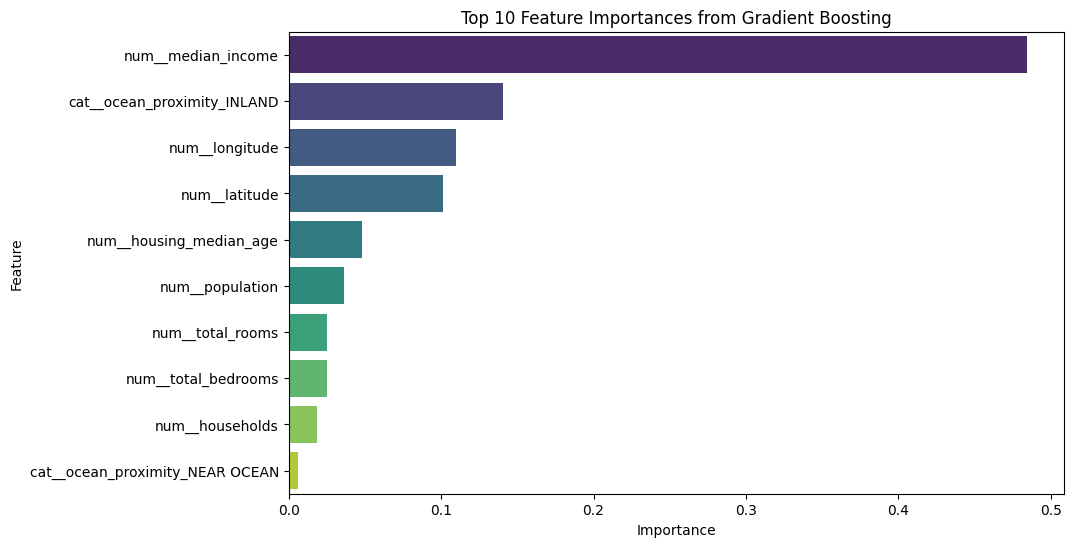

In [18]:
best_model = Gradiient_grid.best_estimator_
model_step = best_model.named_steps['model']
preprocessor_step = best_model.named_steps['preprocessor']
feature_names = preprocessor_step.get_feature_names_out()
feature_importances = model_step.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importances
}).sort_values('importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', hue='feature',legend=False, data=feature_importance_df, palette='viridis')
plt.title('Top 10 Feature Importances from Gradient Boosting')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()



The plot above show the top 10 features based on feature importance

### predict on test data using best hyperparameters


In [19]:
x_test = test.drop('median_house_value', axis=1)
y_test = test['median_house_value']


Gradiient_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), 
    ('model', GradientBoostingRegressor(random_state=42))
    ])

gradient = {
    "model__max_depth": [10],
    "model__n_estimators": [1000]
}
Gradiient_grid = GridSearchCV(estimator=Gradiient_pipeline, param_grid=gradient, scoring=scoring, cv=cv, n_jobs=-1)
Gradiient_grid.fit(x_train, y_train)
y_pred = Gradiient_grid.predict(x_test)
r2 = r2_score(y_test, y_pred)
print("Gradient Boosting - CV R2:", Gradiient_grid.best_score_)
print("Gradient Boosting - Test R2:", r2)

Gradient Boosting - CV R2: 0.8279884482039922
Gradient Boosting - Test R2: 0.8280892188327884


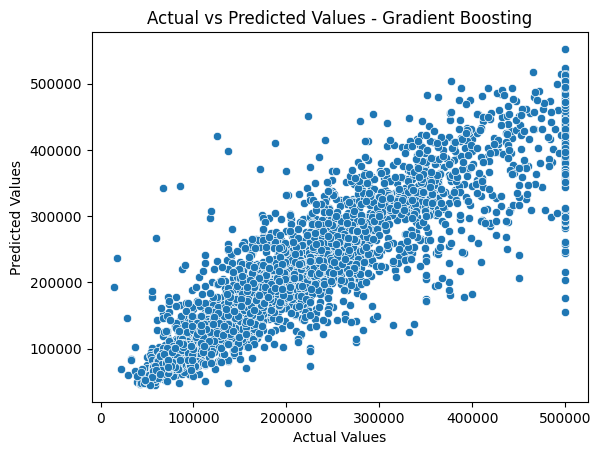

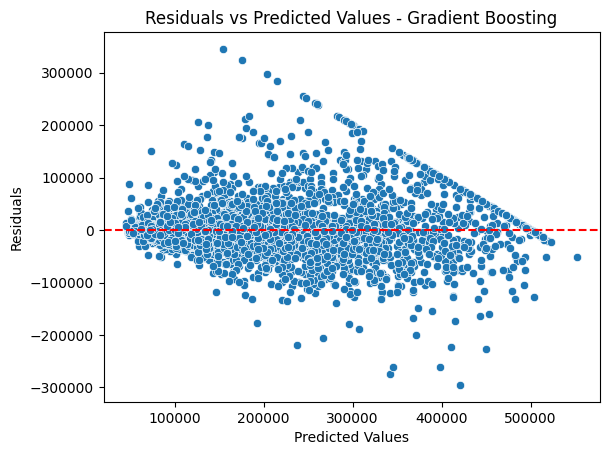

In [20]:
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values - Gradient Boosting')
plt.show()

residuals = y_test - y_pred
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values - Gradient Boosting')
plt.show()


### Advanced approach using K-Means and our model

From our previous analysis, many important details have been revealed that can be used to improve on our analysis.

- First, we observed that the median house value is very correlated to how far the house is to the ocean (Neighbourhood)
- We also observed that not all variables are meaningfull to the model and hence a simpler model will be preferable.
- Our label variable is highly skewed so a log transformation could improve the model.
- From variable importance, we see which variables are important for median house value. These values will bes used in the next steps in investigating if there are natural clusters in the data

In [55]:
x_train1=x_train.copy()
y_train1=y_train.copy()
y_train_log = np.log1p(y_train1)

In [61]:
x_train1.columns

variables=['longitude', 'latitude', 'median_income', 'housing_median_age'
           ]

features =x_train1[variables]


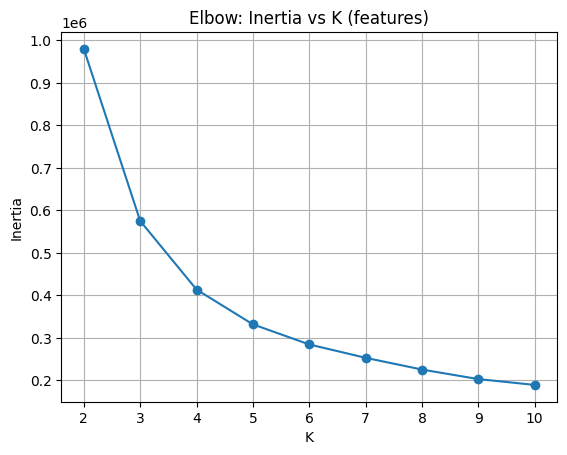

In [62]:
inertias = []
K_range = range(2, 11)

for K in K_range:
    km = KMeans(n_clusters=K, random_state=42, n_init=10)
    km.fit(features)
    inertias.append(km.inertia_)


plt.figure()
plt.plot(list(K_range), inertias, marker="o")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow: Inertia vs K (features)")
plt.grid(True)
plt.show()


Evaluating the graph using the elbow method, we will proceed with k=4

In [63]:
numeric_features = ['longitude', 'latitude', 'housing_median_age','median_income']
categorical_features = ['ocean_proximity']

# Preprocessor
preprocessor1 = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder())
        ]), categorical_features)
    ]
)

In [64]:
features['ocean_proximity'] = x_train1['ocean_proximity']
pipeline1 = Pipeline([
    ('preprocessor', preprocessor1),
    ('kmeans', KMeans(n_clusters=4, random_state=42))
])

features['neighborhood'] = pipeline1.fit_predict(features)

features.head()

,longitude,latitude,median_income,housing_median_age,ocean_proximity,neighborhood
14196,-117.03,32.71,3.2596,33.0,NEAR OCEAN,1
8267,-118.16,33.77,3.8125,49.0,NEAR OCEAN,1
17445,-120.48,34.66,4.1563,4.0,NEAR OCEAN,3
14265,-117.11,32.69,1.9425,36.0,NEAR OCEAN,1
2271,-119.80,36.78,3.5542,43.0,INLAND,2


### adjust preprocessing 


In [65]:
numeric_features = ['longitude', 'latitude', 'housing_median_age','median_income']
categorical_features = ['ocean_proximity','neighborhood']

# Preprocessor
preprocessor2 = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder())
        ]), categorical_features)
    ]
)

### perform analysis on new data with clusters(neighbourhood)

In [66]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor2),  
    ('model', RandomForestRegressor(random_state=42))
    ])

rf_param_grid = {
    "model__n_estimators": [1000],
    "model__max_depth": [10]
}
rf_grid = GridSearchCV(estimator=rf_pipeline, param_grid=rf_param_grid, scoring=scoring, cv=cv, n_jobs=-1
 )
rf_grid.fit(features, y_train_log)
print("Random Forest - CV R2:", rf_grid.best_score_)

Gradiient_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor2), 
    ('model', GradientBoostingRegressor(random_state=42))
    ])
grnbs_param_grid = {
    "model__n_estimators": [1000],
    "model__max_depth": [10]
}
Gradiient_grid = GridSearchCV(estimator=Gradiient_pipeline, param_grid=grnbs_param_grid, scoring=scoring, cv=cv, n_jobs=-1)
Gradiient_grid.fit(features, y_train_log)
print("Gradient Boosting - CV R2:", Gradiient_grid.best_score_)

Random Forest - CV R2: 0.8075217776070058
Gradient Boosting - CV R2: 0.8299841878066951


### Perform analysis on test data with clusters

In [68]:
x_test1 = x_test.copy
y_test1 = y_test.copy
y_test1_log = np.log1p(y_test1)


TypeError: loop of ufunc does not support argument 0 of type method which has no callable log1p method